Ce notebook étudie et analyse la convergence du pricing d'option par arbre binomial vers la solution de l'équation de Black-Scholes

In [78]:
import numpy as np
from binomial.tree import eu_opt_pricing
from binomial.blackscholes import black_scholes_price
import matplotlib.pyplot as plt

In [79]:
# paramètres de l'option
sig=0.2
r=0.05
T=20
S0=50
K=45

In [80]:
def erreur(bs,sig,r,T,S0,K,dt,option_type='call'):
    N = int(round(T/dt))
    binomial_price = eu_opt_pricing(sig, r, T, dt, S0, K, option_type=option_type)
    erreur = np.abs(bs - binomial_price)
    return N, erreur

Avant d'analyser l'erreur, vérifions la vitesse de convergence en traçant $\frac{1}{N}$

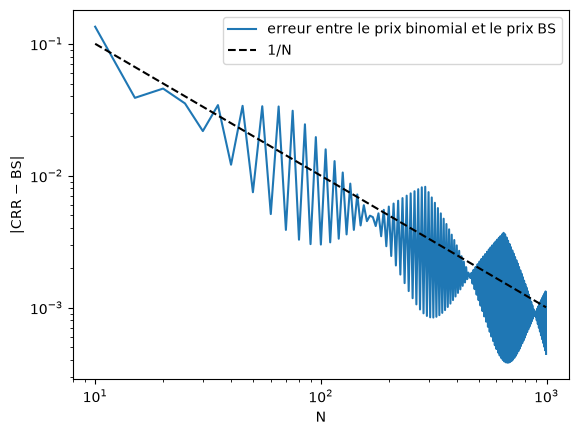

In [81]:
def plot_erreur(sig,r,T,S0,K,option_type='call'):
    absc, errors=[],[]
    bs_price=black_scholes_price(sig, r, T, S0, K, option_type=option_type)
    for N in np.arange(10, 1000, 5):
        dt=T/N
        N, err = erreur(bs_price, sig, r, T, S0, K, dt, option_type=option_type)
        absc.append(N)
        errors.append(err)
    absc = np.array(absc)
    errors = np.array(errors)
    pairs = absc % 2 == 0

    plt.loglog(absc, errors, label='erreur entre le prix binomial et le prix BS')
    plt.xlabel('N')
    plt.ylabel('|CRR − BS|')
    Ns = np.array(absc)
    plt.loglog(Ns,1/Ns,'k--', label='1/N')
    plt.legend()
plot_erreur(sig,r,T,S0,K,option_type='call')


L’erreur décroît globalement à une vitesse compatible avec 1/N.

Analysons maintenant le comportement de l'erreur. On observe deux phénomènes:
 - Un phénomène d'oscillation rapide
 - Un effet "noeud papillon"

Essayons d' expliquer ces phénomènes. 

In [82]:

def plot_parité(sig,r,T,S0,K,option_type='call'):
    absc, errors=[],[]
    i=0
    bs_price=black_scholes_price(sig, r, T, S0, K, option_type=option_type)
    for N in np.arange(10, 1000, 5):
        dt=T/N
        N, err = erreur(bs_price, sig, r, T, S0, K, dt, option_type=option_type)
        absc.append(N)
        errors.append(err)
    absc = np.array(absc)
    errors = np.array(errors)
    pairs = absc % 2 == 0

    plt.loglog(absc[pairs], errors[pairs], '.', label='N pair')
    plt.loglog(absc[~pairs], errors[~pairs], '.', label='N impair')
    plt.xlabel('N')
    plt.ylabel('|CRR − BS|')
    plt.legend()


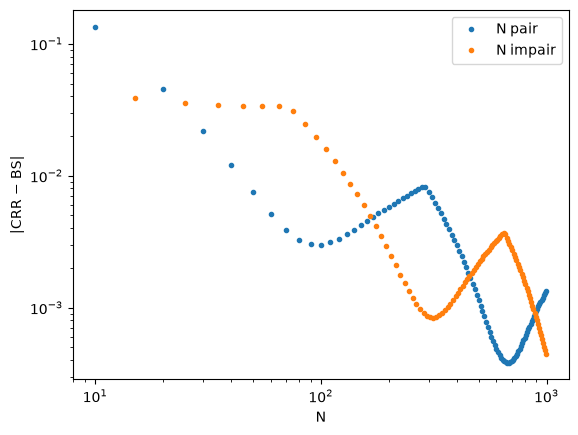

In [83]:
plot_parité(sig,r,T,S0,K,option_type='call')


On peut jouer sur les différents paramètres de l'option pour essayer d'expliquer ce phénomène d'oscillation lente. Après tests, on remarque que la période de cette oscillation est définie par la valeur du strike:

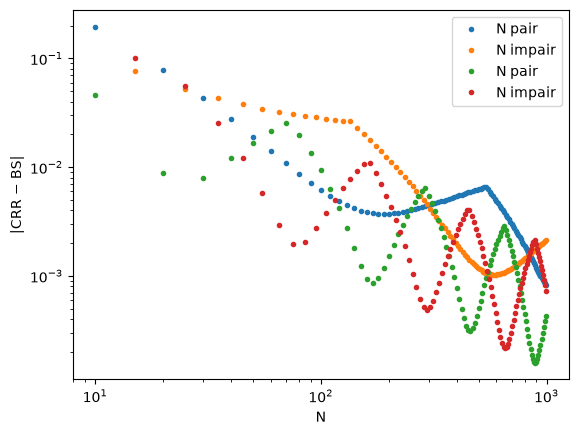

In [84]:
plot_parité(sig,r,T,S0,K*1.2,option_type='call')
plot_parité(sig,r,T,S0,K*0.9,option_type='call')

Les resserrements se déplacent quand K change.

Il peut être intéressant de regarder l'écart entre le strike $K$ et les noeuds terminaux de l'arbre binomial.

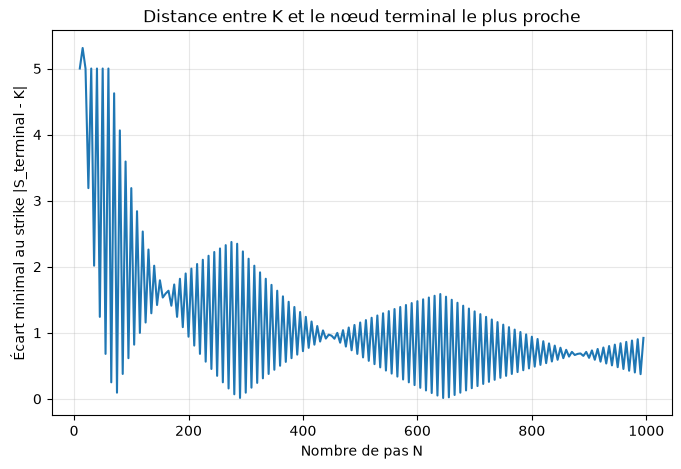

In [85]:
Ns = np.arange(10, 1000, 5)
ecarts = []

for N in Ns:
    dt = T / N
    u = np.exp(sig * np.sqrt(dt))
    d = 1 / u
    j = np.arange(N + 1)
    noeuds_terminaux = S0 * u**j * d**(N - j)
    ecarts.append(np.min(np.abs(noeuds_terminaux - K)))

plt.figure(figsize=(8, 5))
plt.plot(Ns, ecarts)
plt.xlabel("Nombre de pas N")
plt.ylabel("Écart minimal au strike |S_terminal - K|")
plt.title("Distance entre K et le nœud terminal le plus proche")
plt.grid(True, alpha=0.3)
plt.show()

On retrouve cet effet d'oscillation lente. Cela semble indiquer que les oscillations de l'erreur sont causées par la distance entre la valeur du strike $K$ et le noeud final le plus proche.

Vérifions que les valeurs de N pour les resserrements de l'erreur correspondent aux resserrements de l'écart strike-noeud.

Text(0.5, 1.0, 'Erreur de convergence et écart strike-noeud en fonction de N')

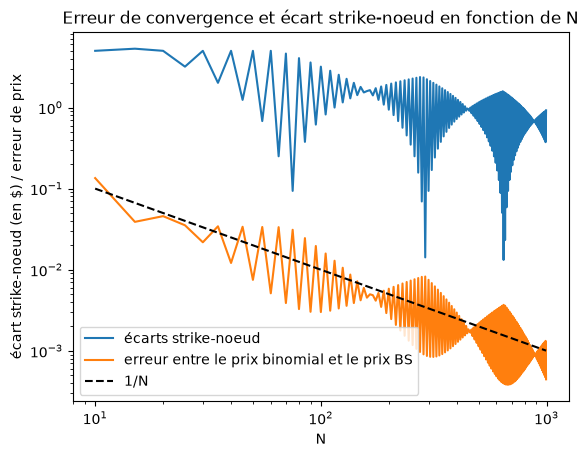

In [86]:
plt.plot(Ns, ecarts, label='écarts strike-noeud')
plot_erreur(sig,r,T,S0,K,option_type='call')
plt.ylabel("écart strike-noeud (en $) / erreur de prix")
plt.title("Erreur de convergence et écart strike-noeud en fonction de N")

*La courbe bleue est une distance en dollars, la orange est une erreur de prix: on compare la position des extremum pour les deux courbes mais pas leurs valeurs.*

On observe une correspondance entre les resserrements de l'erreur et de l'écart noeud-strike: c'est cohérent avec notre hypothèse. Pour la valider, il faudrait donc construire l'arbre binomial de façon à ce qu'on ait toujours un noeud dont la valeur est le strike.